In [1]:
# ── Cell 1: Imports ──────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

print("Libraries loaded ✓")

Libraries loaded ✓


In [2]:
# ── Cell 2: Load Data ────────────────────────────────
# Upload superstore.csv to Colab first (Files sidebar → Upload)
df = pd.read_csv('superstore.csv', encoding='latin-1')

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()


Shape: (9994, 21)
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
# ── Cell 3: Data Cleaning ────────────────────────────

# 1. Fix date columns
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])

# 2. Check for nulls
print("Null values:\n", df.isnull().sum())

# 3. Check duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# 4. Engineer new features
df['Year']          = df['Order Date'].dt.year
df['Month']         = df['Order Date'].dt.to_period('M')
df['Profit Margin'] = np.round((df['Profit'] / df['Sales']) * 100, 2)
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# 5. Discount buckets
df['Discount Band'] = pd.cut(
    df['Discount'],
    bins=[-0.01, 0, 0.2, 0.4, 1.0],
    labels=['No Discount', 'Low (1–20%)', 'Mid (21–40%)', 'High (41%+)']
)

print("\nCleaning complete ✓")
df[['Order Date','Year','Month','Profit Margin','Shipping Days','Discount Band']].head()

Null values:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Duplicate rows: 0

Cleaning complete ✓


,Order Date,Year,Month,Profit Margin,Shipping Days,Discount Band
0,2016-11-08,2016,2016-11,16.00,3,No Discount
1,2016-11-08,2016,2016-11,30.00,3,No Discount
2,2016-06-12,2016,2016-06,47.00,4,No Discount
3,2015-10-11,2015,2015-10,-40.00,7,High (41%+)
4,2015-10-11,2015,2015-10,11.25,7,Low (1–20%)


In [4]:
# ── Cell 4: Business Overview ─────────────────────────
total_sales   = df['Sales'].sum()
total_profit  = df['Profit'].sum()
total_orders  = df['Order ID'].nunique()
avg_margin    = df['Profit Margin'].mean()

print("=" * 45)
print(f"  Total Sales   : ${total_sales:,.0f}")
print(f"  Total Profit  : ${total_profit:,.0f}")
print(f"  Total Orders  : {total_orders:,}")
print(f"  Avg Margin    : {avg_margin:.1f}%")
print("=" * 45)

# Most profitable sub-categories
print("\nTop 5 Sub-Categories by Profit:")
print(df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False).head())

  Total Sales   : $2,297,201
  Total Profit  : $286,397
  Total Orders  : 5,009
  Avg Margin    : 12.0%

Top 5 Sub-Categories by Profit:
Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Name: Profit, dtype: float64


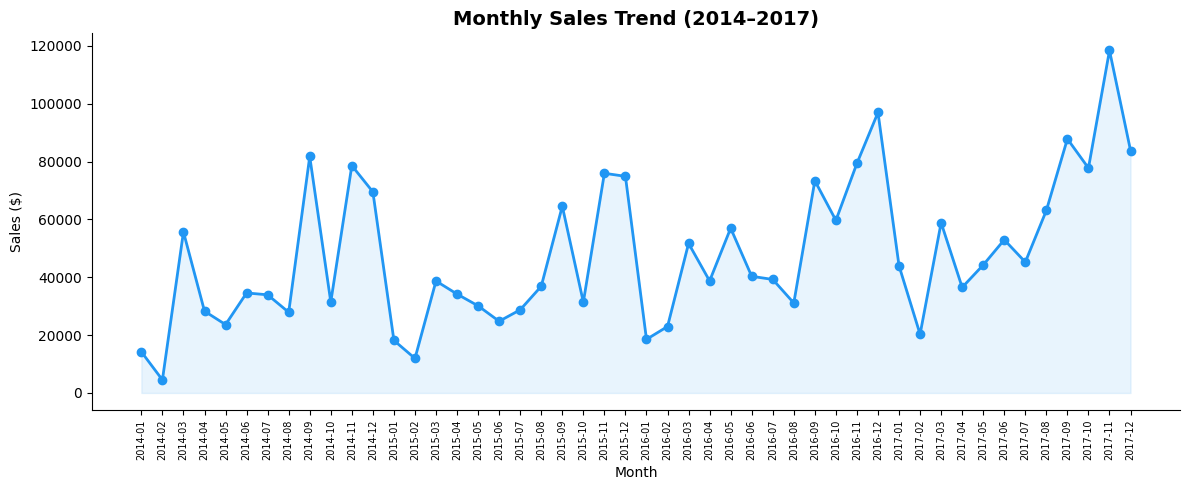

Insight: Clear seasonality — sales spike in Nov–Dec every year.


In [5]:
# ── Cell 5: Monthly Sales Trend ───────────────────────
monthly = (
    df.groupby('Month')['Sales']
      .sum()
      .reset_index()
)
monthly['Month'] = monthly['Month'].astype('str')

fig, ax = plt.subplots()
ax.plot(monthly['Month'], monthly['Sales'], marker='o', linewidth=2, color='#2196F3')
ax.fill_between(monthly['Month'], monthly['Sales'], alpha=0.1, color='#2196F3')
ax.set_title('Monthly Sales Trend (2014–2017)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Sales ($)')
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.savefig('monthly_sales_trend.png', dpi=150)
plt.show()
print("Insight: Clear seasonality — sales spike in Nov–Dec every year.")

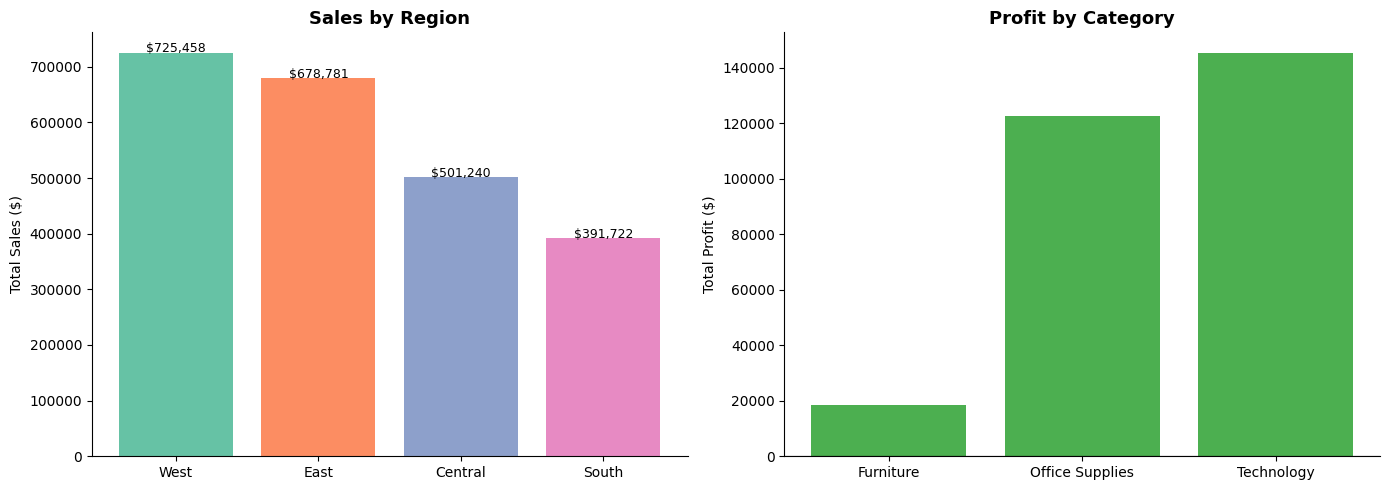

Insight: West leads in sales. Technology is the most profitable category.


In [6]:
# ── Cell 6: Region + Category Analysis ───────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Sales by Region
region_data = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
axes[0].bar(region_data.index, region_data.values, color=sns.color_palette('Set2', 4))
axes[0].set_title('Sales by Region', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Total Sales ($)')
for i, v in enumerate(region_data.values):
    axes[0].text(i, v + 1000, f'${v:,.0f}', ha='center', fontsize=9)

# Right: Profit by Category
cat_profit = df.groupby('Category')['Profit'].sum()
colors = ['#4CAF50' if v > 0 else '#F44336' for v in cat_profit.values]
axes[1].bar(cat_profit.index, cat_profit.values, color=colors)
axes[1].set_title('Profit by Category', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Total Profit ($)')
axes[1].axhline(y=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('region_category.png', dpi=150)
plt.show()
print("Insight: West leads in sales. Technology is the most profitable category.")

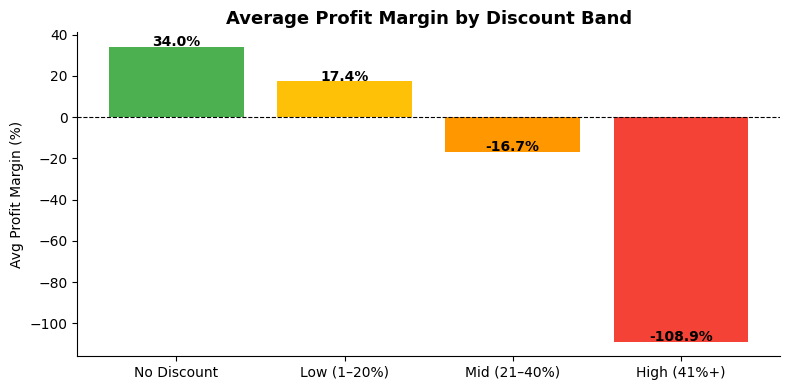

Insight: High discounts (41%+) result in NEGATIVE profit margins — a key business risk.


In [7]:
# ── Cell 7: Discount Impact on Profit ─────────────────
disc_profit = (
    df.groupby('Discount Band', observed=True)['Profit Margin']
      .mean()
      .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#4CAF50', '#FFC107', '#FF9800', '#F44336']
bars = ax.bar(disc_profit['Discount Band'], disc_profit['Profit Margin'], color=colors)
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Average Profit Margin by Discount Band', fontsize=13, fontweight='bold')
ax.set_ylabel('Avg Profit Margin (%)')
for bar, val in zip(bars, disc_profit['Profit Margin']):
    ax.text(bar.get_x() + bar.get_width()/2,
           bar.get_height() + 0.3,
           f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('discount_impact.png', dpi=150)
plt.show()
print("Insight: High discounts (41%+) result in NEGATIVE profit margins — a key business risk.")

In [8]:
# ── Cell 8: Export cleaned data for SQL step ──────────
df.to_csv('superstore_clean.csv', index=False)

# Convert Period column to string before writing to SQLite
import sqlite3
df_sql = df.copy()
df_sql['Month'] = df_sql['Month'].astype(str)

conn = sqlite3.connect('superstore.db')
df_sql.to_sql('sales', conn, if_exists='replace', index=False)
conn.close()

print(f"Exported {len(df):,} rows to superstore_clean.csv ✓")
print("SQLite DB created: superstore.db ✓")

Exported 9,994 rows to superstore_clean.csv ✓
SQLite DB created: superstore.db ✓


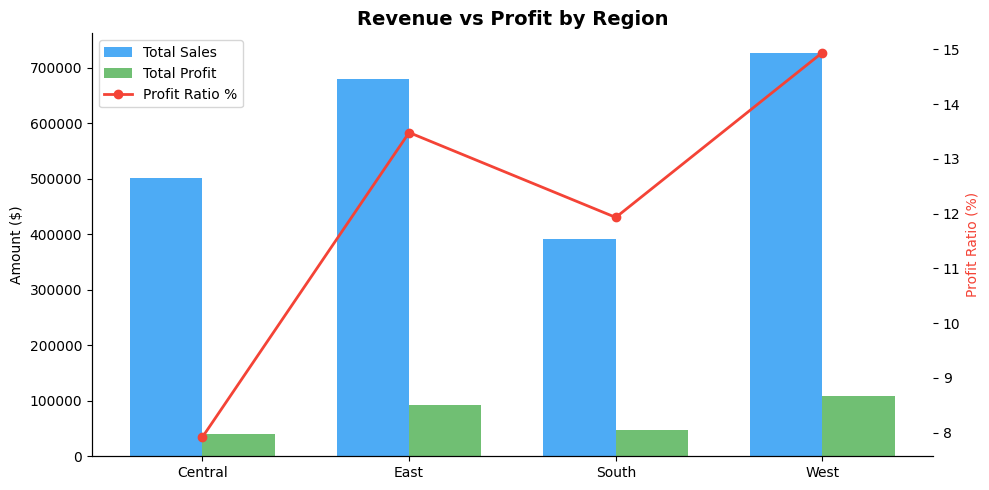

 Region  Total_Sales  Total_Profit  Profit_Ratio
Central  501239.8908    39706.3625          7.92
  South  391721.9050    46749.4303         11.93
   East  678781.2400    91522.7800         13.48
   West  725457.8245   108418.4489         14.94

Insight: Identify regions with high sales but disproportionately low profit ratio.


In [9]:
# ── Q1: Which regions have high revenue but low profit? ───
region_summary = df.groupby('Region').agg(
    Total_Sales   = ('Sales',  'sum'),
    Total_Profit  = ('Profit', 'sum')
).reset_index()

region_summary['Profit_Ratio'] = np.round(
    (region_summary['Total_Profit'] / region_summary['Total_Sales']) * 100, 2
)

x = np.arange(len(region_summary))
width = 0.35

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

bars1 = ax1.bar(x - width/2, region_summary['Total_Sales'],
                width, label='Total Sales', color='#2196F3', alpha=0.8)
bars2 = ax1.bar(x + width/2, region_summary['Total_Profit'],
                width, label='Total Profit', color='#4CAF50', alpha=0.8)
line  = ax2.plot(x, region_summary['Profit_Ratio'],
                color='#F44336', marker='o', linewidth=2, label='Profit Ratio %')
ax1.set_xticks(x)
ax1.set_xticklabels(region_summary['Region'])
ax1.set_ylabel('Amount ($)')
ax2.set_ylabel('Profit Ratio (%)', color='#F44336')
ax1.set_title('Revenue vs Profit by Region', fontsize=14, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('region_revenue_vs_profit.png', dpi=150)
plt.show()

print(region_summary.sort_values('Profit_Ratio').to_string(index=False))
print("\nInsight: Identify regions with high sales but disproportionately low profit ratio.")

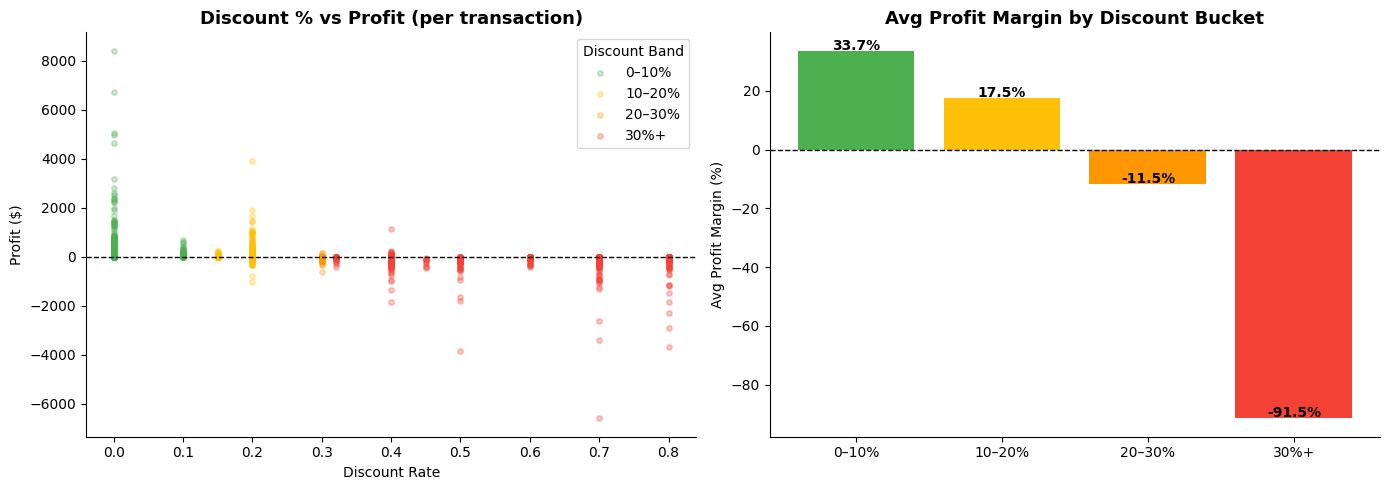

Insight: As discount increases, profit margin drops — 30%+ bucket likely goes negative.


In [10]:
# ── Q2: Do higher discounts increase sales or kill profit? ─

# Rebuild discount bands with your exact buckets
df['Discount Band'] = pd.cut(
    df['Discount'],
    bins=[-0.001, 0.10, 0.20, 0.30, 1.0],
    labels=['0–10%', '10–20%', '20–30%', '30%+']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Scatter — every transaction plotted
colors_map = {'0–10%': '#4CAF50', '10–20%': '#FFC107',
              '20–30%': '#FF9800', '30%+': '#F44336'}
for band, grp in df.groupby('Discount Band', observed=True):
    axes[0].scatter(grp['Discount'], grp['Profit'],
                   alpha=0.3, s=15, label=band, color=colors_map[band])
axes[0].axhline(y=0, color='black', linewidth=1, linestyle='--')
axes[0].set_title('Discount % vs Profit (per transaction)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Discount Rate')
axes[0].set_ylabel('Profit ($)')
axes[0].legend(title='Discount Band')

# Right: Avg profit margin per bucket (bar)
bucket_summary = (
    df.groupby('Discount Band', observed=True)['Profit Margin']
      .mean().reset_index()
)
bar_colors = [colors_map[b] for b in bucket_summary['Discount Band']]
axes[1].bar(bucket_summary['Discount Band'], bucket_summary['Profit Margin'], color=bar_colors)
axes[1].axhline(y=0, color='black', linewidth=1, linestyle='--')
for i, row in bucket_summary.iterrows():
    axes[1].text(i, row['Profit Margin'] + 0.3,
                f"{row['Profit Margin']:.1f}%", ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Avg Profit Margin by Discount Bucket', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Avg Profit Margin (%)')

plt.tight_layout()
plt.savefig('discount_vs_profit_scatter.png', dpi=150)
plt.show()
print("Insight: As discount increases, profit margin drops — 30%+ bucket likely goes negative.")

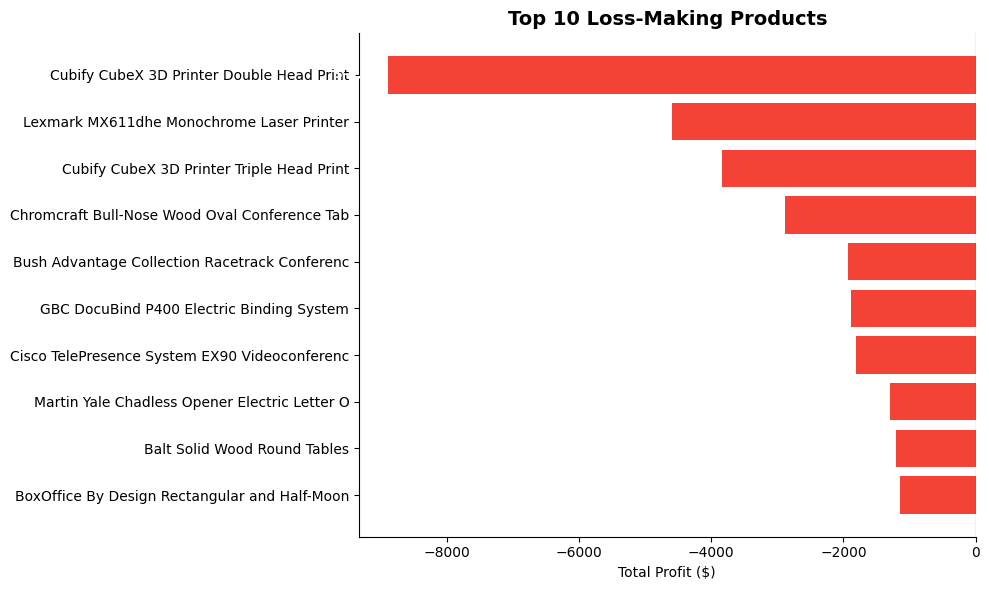


Loss-making products:
                                                     Product Name     Profit
                        Cubify CubeX 3D Printer Double Head Print -8879.9704
                        Lexmark MX611dhe Monochrome Laser Printer -4589.9730
                        Cubify CubeX 3D Printer Triple Head Print -3839.9904
         Chromcraft Bull-Nose Wood Oval Conference Tables & Bases -2876.1156
             Bush Advantage Collection Racetrack Conference Table -1934.3976
                        GBC DocuBind P400 Electric Binding System -1878.1662
            Cisco TelePresence System EX90 Videoconferencing Unit -1811.0784
               Martin Yale Chadless Opener Electric Letter Opener -1299.1836
                                     Balt Solid Wood Round Tables -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables -1148.4375

Total loss from these 10 products: $-29,458


In [11]:
# ── Q3: Which products consistently lose money? ───────────
loss_products = (
    df.groupby('Product Name')['Profit']
      .sum()
      .reset_index()
      .query('Profit < 0')
      .sort_values('Profit')
      .head(10)
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    loss_products['Product Name'].str[:45],
    loss_products['Profit'],
    color='#F44336'
)
ax.axvline(x=0, color='black', linewidth=0.8)
for bar, val in zip(bars, loss_products['Profit']):
    ax.text(val - 10, bar.get_y() + bar.get_height()/2,
           f'${val:,.0f}', va='center', ha='right', fontsize=9, color='white', fontweight='bold')
ax.set_title('Top 10 Loss-Making Products', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Profit ($)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('loss_making_products.png', dpi=150)
plt.show()

print("\nLoss-making products:")
print(loss_products.to_string(index=False))
print(f"\nTotal loss from these 10 products: ${loss_products['Profit'].sum():,.0f}")

## SQL


In [12]:
# ── SQL Setup: connect to superstore.db ───────────────────
import sqlite3
import pandas as pd

conn = sqlite3.connect('superstore.db')

# Helper: run any SQL query and return a DataFrame
def run_sql(query):
    return pd.read_sql_query(query, conn)

# Verify table loaded
print(run_sql("SELECT COUNT(*) as total_rows FROM sales"))
print("\nColumns:", run_sql("PRAGMA table_info(sales)")['name'].tolist())

   total_rows
0        9994

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Year', 'Month', 'Profit Margin', 'Shipping Days', 'Discount Band']


## Question 1

### Which regions generate the highest revenue but lowest profit?

In [13]:
# Q1a: Total sales and profit per region, ranked by sales
q1a = run_sql("""
    SELECT
        Region,
        ROUND(SUM(Sales), 2)              AS Total_Sales,
        ROUND(SUM(Profit), 2)             AS Total_Profit,
        ROUND(SUM(Profit)/SUM(Sales)*100, 2) AS Profit_Ratio_Pct
    FROM sales
    GROUP BY Region
    ORDER BY Total_Sales DESC
""")
print("Q1a — Sales vs Profit by Region:")
print(q1a.to_string(index=False))

Q1a — Sales vs Profit by Region:
 Region  Total_Sales  Total_Profit  Profit_Ratio_Pct
   West    725457.82     108418.45             14.94
   East    678781.24      91522.78             13.48
Central    501239.89      39706.36              7.92
  South    391721.91      46749.43             11.93


In [14]:
# Q1b: Flag regions where profit ratio is below average
q1b = run_sql("""
    WITH region_stats AS (
        SELECT
            Region,
            ROUND(SUM(Sales), 2)                 AS Total_Sales,
            ROUND(SUM(Profit), 2)                AS Total_Profit,
            ROUND(SUM(Profit)/SUM(Sales)*100, 2) AS Profit_Ratio_Pct
        FROM sales
        GROUP BY Region
    ),
    avg_ratio AS (
        SELECT ROUND(AVG(Profit_Ratio_Pct), 2) AS Avg_Ratio
        FROM region_stats
    )
    SELECT
        r.*,
        a.Avg_Ratio,
        CASE
            WHEN r.Profit_Ratio_Pct < a.Avg_Ratio
            THEN 'Underperforming'
            ELSE 'Healthy'
        END AS Status
    FROM region_stats r, avg_ratio a
    ORDER BY r.Profit_Ratio_Pct ASC
""")
print("Q1b — Flagged Regions:")
print(q1b.to_string(index=False))

Q1b — Flagged Regions:
 Region  Total_Sales  Total_Profit  Profit_Ratio_Pct  Avg_Ratio          Status
Central    501239.89      39706.36              7.92      12.07 Underperforming
  South    391721.91      46749.43             11.93      12.07 Underperforming
   East    678781.24      91522.78             13.48      12.07         Healthy
   West    725457.82     108418.45             14.94      12.07         Healthy


## Q2 — discount buckets vs profit

In [15]:
# Q2: Profit margin and avg sales per discount bucket
q2 = run_sql("""
    SELECT
        CASE
            WHEN Discount = 0          THEN '0%  (No discount)'
            WHEN Discount <= 0.10      THEN '0–10%'
            WHEN Discount <= 0.20      THEN '10–20%'
            WHEN Discount <= 0.30      THEN '20–30%'
            ELSE                            '30%+'
        END                                        AS Discount_Band,
        COUNT(*)                                   AS Num_Orders,
        ROUND(AVG(Sales), 2)                       AS Avg_Sales,
        ROUND(AVG(Profit), 2)                      AS Avg_Profit,
        ROUND(AVG(Profit / Sales * 100), 2)        AS Avg_Margin_Pct
    FROM sales
    GROUP BY Discount_Band
    ORDER BY Avg_Margin_Pct DESC
""")
print("Q2 — Discount Buckets vs Profitability:")
print(q2.to_string(index=False))

Q2 — Discount Buckets vs Profitability:
    Discount_Band  Num_Orders  Avg_Sales  Avg_Profit  Avg_Margin_Pct
0%  (No discount)        4798     226.74       66.90           34.02
           10–20%        3709     213.58       24.74           17.48
            0–10%          94     578.40       96.06           15.58
           20–30%         227     454.74      -45.68          -11.55
             30%+        1166     222.59     -107.21          -91.47


## Q3 — loss-making products

In [16]:
# Q3a: Every product that has lost money in total
q3a = run_sql("""
    SELECT
        "Product Name",
        COUNT(*)              AS Times_Ordered,
        ROUND(SUM(Sales), 2)  AS Total_Sales,
        ROUND(SUM(Profit), 2) AS Total_Profit
    FROM sales
    GROUP BY "Product Name"
    HAVING SUM(Profit) < 0
    ORDER BY Total_Profit ASC
    LIMIT 10
""")
print("Q3a — Top 10 Loss-Making Products:")
print(q3a.to_string(index=False))

Q3a — Top 10 Loss-Making Products:
                                                     Product Name  Times_Ordered  Total_Sales  Total_Profit
                        Cubify CubeX 3D Printer Double Head Print              3     11099.96      -8879.97
                        Lexmark MX611dhe Monochrome Laser Printer              4     16829.90      -4589.97
                        Cubify CubeX 3D Printer Triple Head Print              1      7999.98      -3839.99
         Chromcraft Bull-Nose Wood Oval Conference Tables & Bases              5      9917.64      -2876.12
             Bush Advantage Collection Racetrack Conference Table              7      9544.73      -1934.40
                        GBC DocuBind P400 Electric Binding System              6     17965.07      -1878.17
            Cisco TelePresence System EX90 Videoconferencing Unit              1     22638.48      -1811.08
               Martin Yale Chadless Opener Electric Letter Opener              6     16656.20      -1

In [17]:
# Q3b: Which category has the most loss-making products?
q3b = run_sql("""
    SELECT
        Category,
        "Sub-Category",
        COUNT(DISTINCT "Product Name") AS Loss_Products,
        ROUND(SUM(Profit), 2)          AS Total_Loss
    FROM sales
    WHERE Profit < 0
    GROUP BY Category, "Sub-Category"
    ORDER BY Total_Loss ASC
""")
print("Q3b — Loss by Sub-Category:")
print(q3b.to_string(index=False))



Q3b — Loss by Sub-Category:
       Category Sub-Category  Loss_Products  Total_Loss
Office Supplies      Binders            199   -38510.50
      Furniture       Tables             54   -32412.15
     Technology     Machines             34   -30118.67
      Furniture    Bookcases             44   -12152.21
      Furniture       Chairs             71    -9880.84
Office Supplies   Appliances             54    -8629.64
     Technology       Phones             90    -7530.62
      Furniture  Furnishings            104    -6490.91
Office Supplies      Storage             58    -6426.30
Office Supplies     Supplies             12    -3015.62
     Technology  Accessories             38     -930.63
Office Supplies    Fasteners              8      -33.20


In [18]:
q4= run_sql("""SELECT
    "Sub-Category",
    ROUND(SUM(Profit), 2)  AS Total_Profit,
    ROUND(SUM(Sales), 2)   AS Total_Sales,
    COUNT(*)               AS Total_Orders
FROM sales
GROUP BY "Sub-Category"
ORDER BY Total_Profit DESC
LIMIT 5""")
print("Q4 — top 5 most profitable sub categories:")
print(q4.to_string(index=False))
# Close connection when done
conn.close()
print("\nAll SQL queries complete ✓")

Q4 — top 5 most profitable sub categories:
Sub-Category  Total_Profit  Total_Sales  Total_Orders
     Copiers      55617.82    149528.03            68
      Phones      44515.73    330007.05           889
 Accessories      41936.64    167380.32           775
       Paper      34053.57     78479.21          1370
     Binders      30221.76    203412.73          1523

All SQL queries complete ✓


In [19]:
# ── Export query results for Power BI ─────────────────────
conn = sqlite3.connect('superstore.db')

# Re-run queries and save as CSV
pd.read_sql_query("""
    SELECT Region,
           ROUND(SUM(Sales),2) AS Total_Sales,
           ROUND(SUM(Profit),2) AS Total_Profit,
           ROUND(SUM(Profit)/SUM(Sales)*100,2) AS Profit_Ratio_Pct
    FROM sales GROUP BY Region
""", conn).to_csv('pbi_region.csv', index=False)

pd.read_sql_query("""
    SELECT Month, ROUND(SUM(Sales),2) AS Total_Sales
    FROM sales GROUP BY Month ORDER BY Month
""", conn).to_csv('pbi_monthly.csv', index=False)

pd.read_sql_query("""
    SELECT CASE
               WHEN Discount = 0     THEN '0% (No discount)'
               WHEN Discount <= 0.10 THEN '0-10%'
               WHEN Discount <= 0.20 THEN '10-20%'
               WHEN Discount <= 0.30 THEN '20-30%'
               ELSE '30%+' END AS Discount_Band,
           ROUND(AVG(Profit/Sales*100),2) AS Avg_Margin_Pct
    FROM sales GROUP BY Discount_Band
""", conn).to_csv('pbi_discount.csv', index=False)

pd.read_sql_query("""
    SELECT "Product Name", ROUND(SUM(Profit),2) AS Total_Profit
    FROM sales GROUP BY "Product Name"
    HAVING SUM(Profit) < 0
    ORDER BY Total_Profit ASC LIMIT 10
""", conn).to_csv('pbi_loss_products.csv', index=False)

conn.close()
print("4 CSV files exported for Power BI ✓")

4 CSV files exported for Power BI ✓
